In [4]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import pickle as pkl
from tensorflow.keras.layers import Dense, Input
from tensorflow.keras.models import Sequential, Model

# Load dataset using pickle
with open('interpolation_dataset.pkl', 'rb') as f:
    data = pkl.load(f)

print(data)
print(data['X'])
print(data['y'])

# Test ratio
test_ratio = 0.2

# Split dataset into training and testing sets
num_samples = len(data['y'])
num_test_samples = int(num_samples * test_ratio)
# Randomly shuffle indices
indices = np.arange(num_samples)
np.random.shuffle(indices)
test_indices = indices[:num_test_samples]
train_indices = indices[num_test_samples:]
X_train = data['X'][train_indices]
y_train = data['y'][train_indices]
X_test = data['X'][test_indices]
y_test = data['y'][test_indices]



{'X': array([[0.6823519 , 0.05382102, 0.22035988, 0.18437181, 0.1759059 ],
       [0.8120945 , 0.92334497, 0.2765744 , 0.81975454, 0.8898927 ],
       [0.51297045, 0.2449646 , 0.8242416 , 0.21376297, 0.74146706],
       ...,
       [0.04884028, 0.11555603, 0.8701129 , 0.88655764, 0.6181878 ],
       [0.2343695 , 0.930961  , 0.48069727, 0.22636539, 0.18478316],
       [0.30208942, 0.27657416, 0.00934566, 0.6495746 , 0.04375124]],
      shape=(5000, 5), dtype=float32), 'y': array([-0.87565905, -0.5440687 ,  0.25246948, ...,  0.43148616,
        0.9251347 , -0.18895362], shape=(5000,), dtype=float32), 'metadata': {'n_samples': 5000, 'n_features': 5, 'seed': 123, 'feature_names': ['x1', 'x2', 'x3', 'x4', 'x5'], 'target_name': 'y', 'generated_at': '{"timestamp": "2025-10-26T12:31:59"}'}}
[[0.6823519  0.05382102 0.22035988 0.18437181 0.1759059 ]
 [0.8120945  0.92334497 0.2765744  0.81975454 0.8898927 ]
 [0.51297045 0.2449646  0.8242416  0.21376297 0.74146706]
 ...
 [0.04884028 0.11555603 0.8

I0000 00:00:1764771274.287011    3105 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 3537 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4050 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.9


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │           384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,769 (34.25 KB)

 Trainable params: 8,769 (34.25 KB)

...

Epoch 1/100


2025-12-03 14:14:36.205002: I external/local_xla/xla/service/service.cc:163] XLA service 0x774068004f30 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2025-12-03 14:14:36.205031: I external/local_xla/xla/service/service.cc:171]   StreamExecutor device (0): NVIDIA GeForce RTX 4050 Laptop GPU, Compute Capability 8.9
2025-12-03 14:14:36.240503: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2025-12-03 14:14:36.388408: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:473] Loaded cuDNN version 91002


 69/100 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.2873

I0000 00:00:1764771277.317982    4297 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


100/100 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 0.2614 - val_loss: 0.2336
Epoch 2/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.1921 - val_loss: 0.1337
Epoch 3/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.1163 - val_loss: 0.0982
Epoch 4/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0810 - val_loss: 0.0628
Epoch 5/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0570 - val_loss: 0.0393
Epoch 6/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0343 - val_loss: 0.0274
Epoch 7/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0229 - val_loss: 0.0208
Epoch 8/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0172 - val_loss: 0.0162
Epoch 9/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0156 - val_loss: 0.0150
Epoch 10/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0149 - val_loss: 0.0139
Epoch 11/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0129 - val_loss: 0.0122
Epoch 12/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step

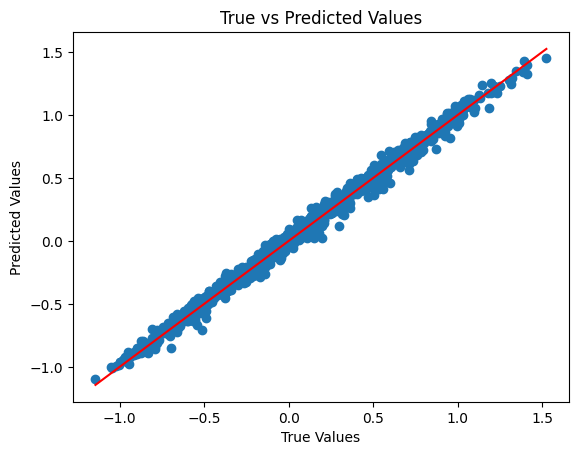

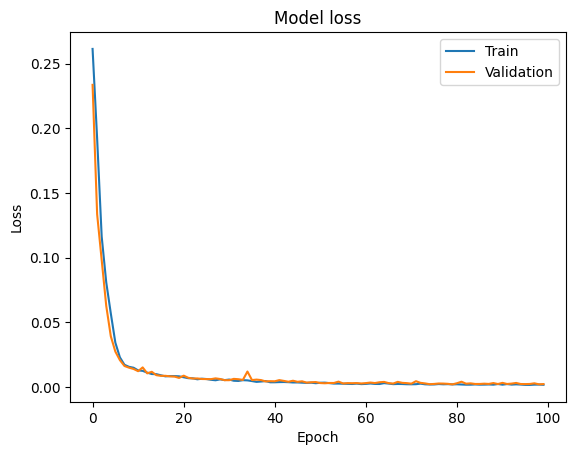

In [5]:
# Build the model. Use 3 hidden layers, 64 neurons in each, ReLU activation
model = Sequential([
    Input(shape=(X_train.shape[1],)),
    Dense(64, activation='relu'),
    Dense(64, activation='relu'),
    Dense(64, activation='relu'),
    Dense(1)  # Output layer for regression
])

# Compile the model
model.compile(optimizer='adam', loss='mse')
model.summary()
# Train the model
history = model.fit(X_train, y_train, epochs=100, batch_size=32, validation_split=0.2)
# Evaluate the model
test_loss = model.evaluate(X_test, y_test)
print(f'Test Loss: {test_loss}')
# Make predictions
y_pred = model.predict(X_test)
# Plot true vs predicted values
plt.scatter(y_test, y_pred)
plt.xlabel('True Values')
plt.ylabel('Predicted Values')
plt.title('True vs Predicted Values')
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='red')  # Diagonal line
plt.show()
# Plot training & validation loss values
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper right')
plt.show()

In [6]:
# Evaluate model performance using MAE, MSE, R2
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(f'Mean Absolute Error: {mae}')
print(f'Mean Squared Error: {mse}')
print(f'R^2 Score: {r2}')

Mean Absolute Error: 0.03530185669660568
Mean Squared Error: 0.0020755939185619354
R^2 Score: 0.9925733804702759


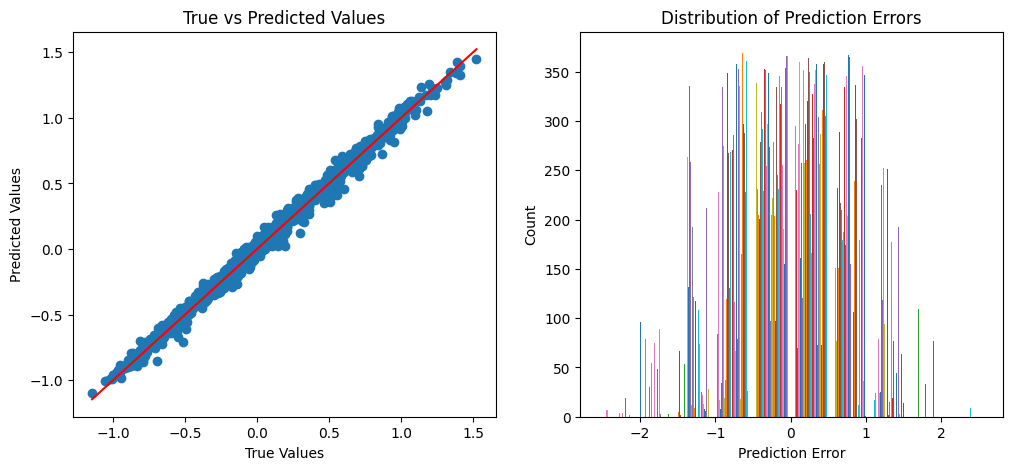

In [11]:
# Produce diagnostic plots
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.scatter(y_test, y_pred)
plt.xlabel('True Values')
plt.ylabel('Predicted Values')
plt.title('True vs Predicted Values')
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='red')  # Diagonal line
plt.subplot(1, 2, 2)
plt.hist(y_test - y_pred, bins=10, histtype='bar')
plt.xlabel('Prediction Error')
plt.ylabel('Count')
plt.title('Distribution of Prediction Errors')
plt.show()

In [12]:
# Do this all using OOP

class PolynomialRegressor:
    def __init__(self, num_layers, units_per_layer, optimiser, learning_rate, activation, datapath=None):
        self.num_layers = num_layers
        self.units_per_layer = units_per_layer
        self.optimiser = optimiser
        self.learning_rate = learning_rate
        self.activation = activation
        self.datapath = datapath
        self.model = None
        self.history = None
    
        if datapath:
            self.load_data(datapath)

    def load_data(self, datapath):
        with open(datapath, 'rb') as f:
            data = pkl.load(f)
        self.X = data['X']
        self.y = data['y']
        self.N_samples = len(self.y)

    def split_data(self, test_ratio):
        num_test_samples = int(self.N_samples * test_ratio)
        indices = np.arange(self.N_samples)
        np.random.shuffle(indices)
        test_indices = indices[:num_test_samples]
        train_indices = indices[num_test_samples:]
        self.X_train = self.X[train_indices]
        self.y_train = self.y[train_indices]
        self.X_test = self.X[test_indices]
        self.y_test = self.y[test_indices]

    def build_model(self):
        layers = [Input(shape=(self.X_train.shape[1],))]
        for _ in range(self.num_layers):
            layers.append(Dense(self.units_per_layer, activation=self.activation))
        layers.append(Dense(1))  # Output layer for regression
        self.model = Sequential(layers)
        optimiser_instance = tf.keras.optimizers.get({
            'class_name': self.optimiser,
            'config': {'learning_rate': self.learning_rate}
        })
        self.model.compile(optimizer=optimiser_instance, loss='mse')
        self.model.summary()

    def train(self, epochs, batch_size, validation_split):
        self.history = self.model.fit(self.X_train, self.y_train, epochs=epochs, batch_size=batch_size, validation_split=validation_split)

    def evaluate(self):
        test_loss = self.model.evaluate(self.X_test, self.y_test)
        print(f'Test Loss: {test_loss}')
        y_pred = self.model.predict(self.X_test)
        mae = mean_absolute_error(self.y_test, y_pred)
        mse = mean_squared_error(self.y_test, y_pred)
        r2 = r2_score(self.y_test, y_pred)
        print(f'Mean Absolute Error: {mae}')
        print(f'Mean Squared Error: {mse}')
        print(f'R^2 Score: {r2}')
        return y_pred, mae, mse, r2
    
    def plot_diagnostics(self, y_pred):
        plt.figure(figsize=(12, 5))
        plt.subplot(1, 2, 1)
        plt.scatter(self.y_test, y_pred)
        plt.xlabel('True Values')
        plt.ylabel('Predicted Values')
        plt.title('True vs Predicted Values')
        plt.plot([min(self.y_test), max(self.y_test)], [min(self.y_test), max(self.y_test)], color='red')  # Diagonal line
        plt.subplot(1, 2, 2)
        plt.hist(self.y_test - y_pred, bins=10, histtype='bar')
        plt.xlabel('Prediction Error')
        plt.ylabel('Count')
        plt.title('Distribution of Prediction Errors')
        plt.show()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 64)             │           384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,769 (34.25 KB)

 Trainable params: 8,769 (34.25 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - loss: 0.2560 - val_loss: 0.2449
Epoch 2/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.2048 - val_loss: 0.1616
Epoch 3/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.1209 - val_loss: 0.0983
Epoch 4/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0810 - val_loss: 0.0653
Epoch 5/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0576 - val_loss: 0.0482
Epoch 6/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0422 - val_loss: 0.0357
Epoch 7/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0298 - val_loss: 0.0259
Epoch 8/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0237 - val_loss: 0.0309
Epoch 9/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0186 - val_loss: 0.0185
Epoch 10/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0160 - val_loss: 0.0180
Epoch 11/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0135 - val_loss: 0.0140
Epoch 12/100
100/100 ━━━━━━━━━━━━━━━━━━━

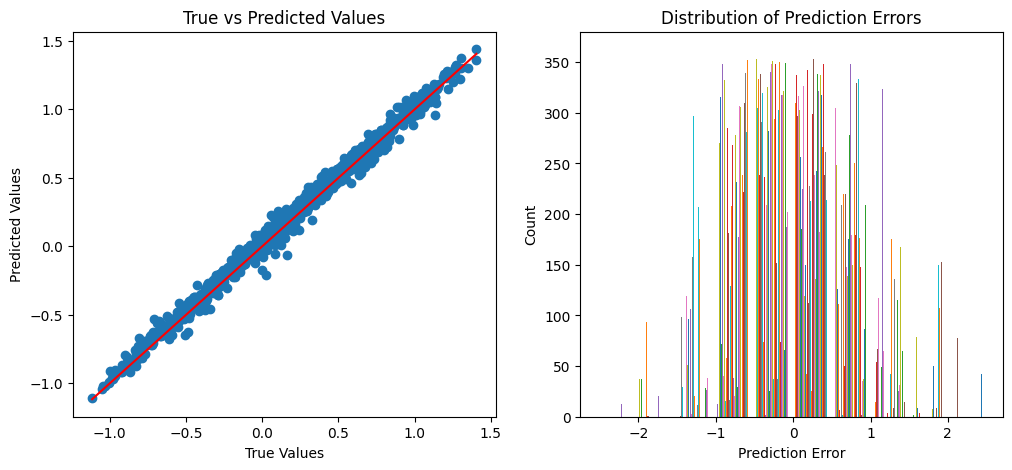

Time elapsed: 81.7201 seconds
Memory used: 100665.3262 KB


In [13]:
# Build a profiler to return time, memory, and complexity usage
import time
import tracemalloc

class Profiler:
    def __init__(self):
        self.start_time = None
        self.end_time = None
        self.start_memory = None
        self.end_memory = None

    def start(self):
        self.start_time = time.time()
        tracemalloc.start()
        self.start_memory = tracemalloc.get_traced_memory()[1]

    def stop(self):
        self.end_time = time.time()
        self.end_memory = tracemalloc.get_traced_memory()[1]
        tracemalloc.stop()

    def report(self):
        time_elapsed = self.end_time - self.start_time
        memory_used = self.end_memory - self.start_memory
        print(f'Time elapsed: {time_elapsed:.4f} seconds')
        print(f'Memory used: {memory_used / 1024:.4f} KB')

# Example usage of the PolynomialRegressor and Profiler classes
profiler = Profiler()
profiler.start()
regressor = PolynomialRegressor(num_layers=3, units_per_layer=64, optimiser='adam', learning_rate=0.001, activation='relu', datapath='interpolation_dataset.pkl')
regressor.split_data(test_ratio=0.2)
regressor.build_model()
regressor.train(epochs=100, batch_size=32, validation_split=0.2)
y_pred, mae, mse, r2 = regressor.evaluate()
regressor.plot_diagnostics(y_pred)
profiler.stop()
profiler.report()

In [14]:
# Profile time and memory usage for a range of input number of layers, units per layer, epochs, optimisers, and activations

layer_options = [2, 3]
unit_options = [32, 64]
epoch_options = [50, 100]
optimiser_options = ['adam', 'sgd']
activation_options = ['relu', 'tanh']

for layers in layer_options:
    for units in unit_options:
        for epochs in epoch_options:
            for optimiser in optimiser_options:
                for activation in activation_options:
                    print(f'Profiling with layers: {layers}, units: {units}, epochs: {epochs}, optimiser: {optimiser}, activation: {activation}')
                    profiler = Profiler()
                    profiler.start()
                    regressor = PolynomialRegressor(num_layers=layers, units_per_layer=units, optimiser=optimiser, learning_rate=0.001, activation=activation, datapath='interpolation_dataset.pkl')
                    regressor.split_data(test_ratio=0.2)
                    regressor.build_model()
                    regressor.train(epochs=epochs, batch_size=32, validation_split=0.2)
                    y_pred, mae, mse, r2 = regressor.evaluate()
                    profiler.stop()
                    profiler.report()

                    

Profiling with layers: 2, units: 32, epochs: 50, optimiser: adam, activation: relu


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_8 (Dense)                 │ (None, 32)             │           192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,281 (5.00 KB)

 Trainable params: 1,281 (5.00 KB)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_116 (Dense)               │ (None, 64)             │           384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_117 (Dense)               │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_118 (Dense)               │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_119 (Dense)               │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,769 (34.25 KB)

 Trainable params: 8,769 (34.25 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 3s 18ms/step - loss: 0.3570 - val_loss: 0.3193
Epoch 2/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.2913 - val_loss: 0.3063
Epoch 3/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.2838 - val_loss: 0.3009
Epoch 4/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.2786 - val_loss: 0.2937
Epoch 5/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.2745 - val_loss: 0.2890
Epoch 6/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.2714 - val_loss: 0.2850
Epoch 7/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.2691 - val_loss: 0.2830
Epoch 8/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.2671 - val_loss: 0.2817
Epoch 9/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.2654 - val_loss: 0.2773
Epoch 10/100
100/100 ━━━━━━━━━━━━━━━━━━━━ -1s -10885us/step - loss: 0.2643 - val_loss: 0.2776
Epoch 11/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.2633 - val_loss: 0.2751
Epoch 12/100
100/100 ━━━━━━━━━━━